In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

In [3]:
# ognuwro = dl.load_sample(
#     run_number = "1",
#     category = "runs",
#     dataset = "nuwro_fd",
#     append="",
#     variation="cv",
#     loadsystematics=False,
#     loadpi0variables=False,
#     loadshowervariables=False,
#     loadrecoveryvars=False,
#     loadnumuvariables=False,
#     use_lee_weights=False,
#     use_bdt=False,
#     pi0scaling=0,
#     load_crt_vars=False,
#     load_numu_tki=False,
#     load_nue_tki=False,
#     #full_path="/exp/uboone/data/users/mmoudgal/PELEE_2023_Samples/run1/prodnuwro_run1_intrinsic_nue_overlay_reco2_ana.root",
#     full_path="/exp/uboone/data/users/mmoudgal/PELEE_2023_Samples/run1/high_stat_prodgenie_bnb_nu_overlay_DetVar_Run1_NuWro_reco2_reco2.root",
#     keep_columns=None,
# )

In [4]:
import uproot

variables = ["nu_e", "ccnc", "nu_pdg", "npi0", "npion", "nproton", "weightsGenie"]

fold = "nuselection"
tree = "NeutrinoSelectionFilter"
#up = uproot.open('/exp/uboone/data/users/mmoudgal/PELEE_2023_Samples/run1/high_stat_prodgenie_bnb_nu_overlay_DetVar_Run1_NuWro_reco2_reco2.root')[fold][tree]
up = uproot.open('/exp/uboone/data/users/mmoudgal/PELEE_2023_Samples/run1/overlay_peleeTuple_uboone_v08_00_00_70_run1_dirt.root')[fold][tree]
#up = uproot.open(data_path)[fold][tree]
df = up.pandas.df(variables, flatten=False)

In [9]:
print(len(df["weightsGenie"][10740]))
df["weightsGenie"].head(60)

100


entry
0     [184, 675, 73, 402, 3229, 2317, 1599, 669, 942...
1     [1154, 1099, 930, 1167, 813, 1248, 1030, 1142,...
2     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3     [735, 576, 239, 1465, 0, 198, 1139, 523, 271, ...
4     [1240, 1147, 829, 1278, 586, 1474, 980, 1230, ...
5     [1045, 353, 461, 1362, 1384, 521, 1403, 447, 1...
6     [775, 191, 401, 1430, 1223, 428, 1597, 434, 40...
7     [1347, 1217, 820, 1398, 531, 1677, 1003, 1336,...
8     [1263, 877, 699, 1148, 1564, 1274, 1133, 1107,...
9     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
10    [587, 275, 147, 1324, 554, 548, 1073, 622, 121...
11    [866, 1009, 1046, 970, 1048, 1055, 1090, 1011,...
12    [1327, 1220, 843, 1377, 569, 1617, 1019, 1325,...
13    [1409, 1458, 761, 1617, 232, 2195, 876, 1600, ...
14    [2450, 395, 1005, 889, 568, 2085, 1259, 869, 1...
15    [1333, 1086, 875, 1286, 1003, 1410, 1132, 1200...
16    [1170, 1406, 901, 815, 249, 862, 700, 1492, 47...
17    [892, 705, 988, 732, 559, 544, 682, 

In [6]:
for key in up.keys():
    print(key)

b'selected'
b'run'
b'sub'
b'evt'
b'trk_id'
b'shr_id'
b'trk2_id'
b'shr2_id'
b'shr_energy_tot'
b'shr_energy'
b'shr_energy_tot_cali'
b'shr_energy_cali'
b'shr_theta'
b'shr_phi'
b'shr_pca_0'
b'shr_pca_1'
b'shr_pca_2'
b'shr_px'
b'shr_py'
b'shr_pz'
b'shr_openangle'
b'shr_tkfit_start_x'
b'shr_tkfit_start_y'
b'shr_tkfit_start_z'
b'shr_tkfit_theta'
b'shr_tkfit_phi'
b'shr_start_x'
b'shr_start_y'
b'shr_start_z'
b'shr_dedx_Y'
b'shr_dedx_V'
b'shr_dedx_U'
b'shr_dedx_Y_cali'
b'shr_dedx_V_cali'
b'shr_dedx_U_cali'
b'shr_tkfit_dedx_Y'
b'shr_tkfit_dedx_V'
b'shr_tkfit_dedx_U'
b'shr_tkfit_dedx_max'
b'shr_tkfit_nhits_Y'
b'shr_tkfit_nhits_V'
b'shr_tkfit_nhits_U'
b'shr_llrpid_dedx_Y'
b'shr_llrpid_dedx_V'
b'shr_llrpid_dedx_U'
b'shr_llrpid_dedx'
b'shr_tkfit_dedx_Y_alt'
b'shr_tkfit_dedx_V_alt'
b'shr_tkfit_dedx_U_alt'
b'shr_tkfit_nhits_Y_alt'
b'shr_tkfit_nhits_V_alt'
b'shr_tkfit_nhits_U_alt'
b'trkfit'
b'shr_tkfit_npoints'
b'shr_tkfit_npointsvalid'
b'shr_trkfitmedangle'
b'shrmoliereavg'
b'shrmoliererms'
b'shr1shr2m

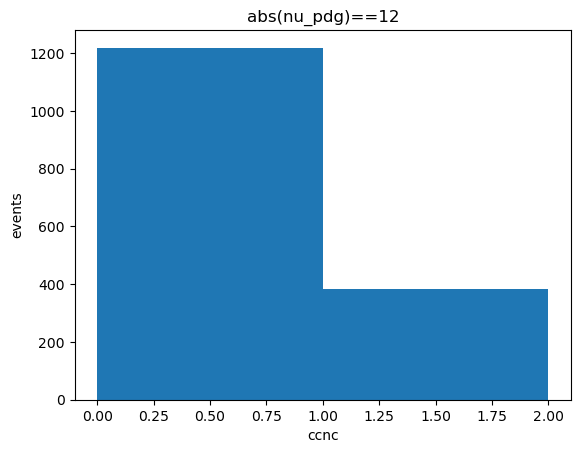

In [13]:
query_nue = "abs(nu_pdg)==12"
nue_all = df.query(query_nue, engine='python')
plt.hist(nue_all["ccnc"], [0,1,2])
plt.xlabel("ccnc")
plt.ylabel("events")
plt.title(query_nue)
plt.savefig(f'og_nuwroFD_nue_ccnc.pdf', bbox_inches='tight')

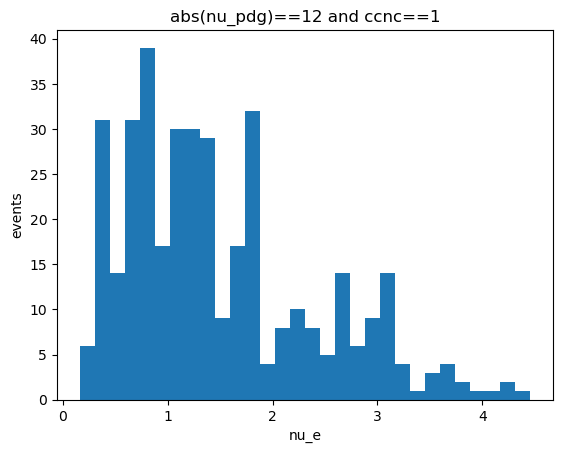

In [18]:
query_nue_nc = "abs(nu_pdg)==12 and ccnc==1"
nue_nc = df.query(query_nue_nc, engine='python')
plt.hist(nue_nc["nu_e"], 30)
plt.xlabel("nu_e")
plt.ylabel("events")
plt.title(query_nue_nc)
plt.savefig(f'og_nuwroFD_nue_nc_nu_energy.pdf', bbox_inches='tight')

In [ ]:
keep_vars = [
    "Signal_1e1p", "mc_signal_1e1p", "nu_pdg", "TrueElecIdx", "TrueLeadProtonIdx", "InFV", "HasNoMesons", "TrueNElec", "TrueNProt", 
    "TrueDeltaPT_1e1p", "TrueDeltaAlphaT_1e1p", "TruePN_1e1p", "TrueAlpha3D_1e1p",
    "TrueLeadProtonKE_1e1p", "TrueLeadProtonModMom_1e1p", "TrueLeadProtonE_1e1p", "TrueLeadProtonMomX_1e1p", "TrueLeadProtonMomY_1e1p", "TrueLeadProtonMomZ_1e1p",
    "TrueElecKE_1e1p", "TrueElecModMom_1e1p", "TrueElecE_1e1p", "TrueElecMomX_1e1p", "TrueElecMomY_1e1p", "TrueElecMomZ_1e1p",

    "TrueDeltaPT", "TrueDeltaAlphaT", "TruePN", "TrueAlpha3D",
    "mc_KE_prot", "mc_p_prot", "mc_E_prot", "mc_px_prot", "mc_py_prot", "mc_pz_prot",
    "mc_KE_elec", "mc_p_elec", "mc_E_elec", "mc_px_elec", "mc_py_elec", "mc_pz_elec",

    "Sel_1e1p", "sel_1e1p_w_cuts", "RecoElectronCandidateIdx", "RecoLeadProtonCandidateIdx", "InFV_reco",
    "RecoElecPassMomCut", "RecoLeadProtonPassMomCut", "n_reco_tracks", "n_reco_showers",
    "RecoDeltaPT_1e1p", "RecoDeltaAlphaT_1e1p", "RecoPN_1e1p", "RecoAlpha3D_1e1p", #"RecoECal_1e1p", "Reco_mag_q_1e1p", "RecoPL_1e1p",
    "RecoLeadProtonKE_1e1p", "RecoLeadProtonModMom_1e1p", "RecoLeadProtonMomX_1e1p", "RecoLeadProtonMomY_1e1p", "RecoLeadProtonMomZ_1e1p",
    "RecoElecE", "RecoElecModMom", "RecoElecMomX", "RecoElecMomY", "RecoElecMomZ",

    "RecoLeadProton_trk_len", "RecoLeadProton_trk_trunk_dEdx_y", "RecoLeadProton_dEdx_y_per_trklen",
    "RecoLeadProtonCandidate_trk_pid", "RecoElectronCandidate_shr_pid", "RecoElectron_conversion_dist",

    "nproton", "npion", "npi0", "nelec", "nmuon", "isVtxInFiducial", "elec_e", "proton_ke",
    "nslice", "selected", "shr_energy_tot_cali", "_opfilter_pe_beam", "_opfilter_pe_veto", "bnbdata", "extdata",
    "CosmicIPAll3D", "hits_ratio", "shrmoliereavg", "subcluster", "trkfit", "trkshrhitdist2", "tksh_distance",
    "shr_tkfit_nhits_tot", "shr_tkfit_dedx_max", "tksh_angle", "shr_trk_len", "reco_e",
    "trkpid", "trk_len", "n_showers_contained", "protonenergy_corr", "n_tracks_contained",
    "pi0_radlen1", "pi0_radlen2", "pi0_score", "nonpi0_score", "bkg_score", "trk_id",

    "RecoDeltaPT", "RecoDeltaAlphaT", "RecoPN", "RecoAlpha3D", #"RecoECal", "Reco_mag_q", "RecoPL",
    "RecoLeadProtonKE", "RecoLeadProtonModMom", "RecoLeadProtonMomX", "RecoLeadProtonMomY", "RecoLeadProtonMomZ",

    # "InFV_1muNp", "TrueMuonIdx_1muNp", "TrueLeadProtonIdx_1muNp", "TrueNProt_1muNp", "TrueFSPions_1muNp", "Signal_1mu1p", 
    # "TrueDeltaPT_1mu1p", "TrueDeltaAlphaT_1mu1p", "TruePN_1mu1p", "TrueAlpha3D_1mu1p",
    # "TrueLeadProtonE_1muNp", "TrueLeadProtonMomX_1muNp", "TrueLeadProtonMomY_1muNp", "TrueLeadProtonMomZ_1muNp",
    # "TrueMuonE_1muNp", "TrueMuonMomX_1muNp", "TrueMuonMomY_1muNp", "TrueMuonMomZ_1muNp",

    # "sel_CC1p0pi", "InFV_reco_1muNp", "MuonCandidateIdx_1muNp", "LeadProtonIdx_1muNp", "LeadProtonPassMomentumCut_1muNp", "PFPStartsInPCV_1muNp", "PassTopoScoreCut_1muNp",
    # "PassNuMuCCSelection_1muNp", "NoRecoShowers_1muNp", "MuonContained_1muNp", "PassMuonMomentumCut_1muNp", "PassMuonQualCut_1muNp",
    # "LeadProtonPassMomentumCut_1muNp", "NProtons_1muNp",
    # "RecoDeltaPT_1mu1p", "RecoDeltaAlphaT_1mu1p", "RecoPN_1mu1p", "RecoAlpha3D_1mu1p", "RecoECal_1mu1p", "RecoPL_1mu1p",
    # "RecoLeadProtonE_1muNp", "RecoLeadProtonMomentum_1muNp", "RecoLeadProtonMomX_1muNp", "RecoLeadProtonMomY_1muNp", "RecoLeadProtonMomZ_1muNp", 
    # "RecoMuonE_1muNp", "RecoMuonMomentum_1muNp", "RecoMuonMomX_1muNp", "RecoMuonMomY_1muNp", "RecoMuonMomZ_1muNp",
]

rundata, mc_weights, data_pot = dl.load_runs(
    "1_nuwrofd",
    data="nuwro_fd",
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=True,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=True,
    load_lee=False,
    load_numu_tki=False,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=True,
    load_crt_vars=False,
    enable_cache=True,
)